# HDB Resale Price Prediction — Baseline Model

**Goal:** Predict `resale_price` using LightGBM, XGBoost, CatBoost with fixed hyperparameters and a simple blend.

**Data:** `windsurf_train.csv` (150,634 rows × 54 columns)

## 1. Imports and Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 60)
SEED = 42
N_FOLDS = 5
np.random.seed(SEED)
print("Libraries loaded.")

Libraries loaded.


## 2. Load Data

In [2]:
df = pd.read_csv("windsurf_train.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (150634, 54)


,town,flat_type,block,street_name,floor_area_sqm,flat_model,resale_price,Tranc_Year,mid_storey,full_flat_type,max_floor_lvl,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,Latitude,Longitude,Mall_Nearest_Distance,Mall_Within_500m,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,bus_interchange,mrt_interchange,bus_stop_nearest_distance,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,lease_remaining_year,time_index,Mall_500m_1km,Mall_1km_2km
0,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,90.0,Model A,680000.0,2016,11,4 ROOM Model A,25,0,0,0,0,142,0,0,0,96,46,0,0,0,0,0,0,0,1.314299,103.872828,1037.741301,0,154.753357,1,3,13,84,60,330.083069,0,0,29.427395,1138.633422,Geylang Methodist School,78,1,1138.633422,Geylang Methodist School,224,0,89,1.465786,0,4
1,BISHAN,5 ROOM,153,BISHAN ST 13,130.0,Improved,665000.0,2012,8,5 ROOM Improved,9,0,0,0,0,112,0,0,0,56,56,0,0,0,0,0,0,0,1.346086,103.855078,855.883601,0,640.151925,0,1,7,80,77,903.659703,1,1,58.207761,415.607357,Kuo Chuan Presbyterian Primary School,45,1,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,74,1.344415,1,2
2,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,144.0,Apartment,838000.0,2013,14,EXECUTIVE Apartment,16,0,0,0,0,90,0,0,0,0,30,60,0,0,0,0,0,0,1.343867,103.760535,1460.436493,0,1762.082341,0,0,2,84,95,1334.251197,1,0,214.747860,498.849039,Keming Primary School,39,0,180.074558,Yusof Ishak Secondary School,188,0,83,1.188292,0,5


## 3. Feature Engineering & Preprocessing

In [3]:
TARGET = "resale_price"

# --- Derived features (original) ---
df["price_per_sqm"] = df["resale_price"] / df["floor_area_sqm"]
df["age_at_sale"] = 99 - df["lease_remaining_year"]
df["storey_ratio"] = df["mid_storey"] / df["max_floor_lvl"]
df["Hawker_500m_1km"] = df["Hawker_Within_1km"] - df["Hawker_Within_500m"]
df["Hawker_1km_2km"] = df["Hawker_Within_2km"] - df["Hawker_Within_1km"]
df["total_room_sold"] = (
    df["1room_sold"] + df["2room_sold"] + df["3room_sold"]
    + df["4room_sold"] + df["5room_sold"] + df["exec_sold"]
    + df["multigen_sold"] + df["studio_apartment_sold"]
)
df["total_rental"] = df["1room_rental"] + df["2room_rental"] + df["3room_rental"] + df["other_room_rental"]

# --- Columns to drop ---
drop_cols = ["block", "street_name", "full_flat_type", "price_per_sqm"]
df.drop(columns=drop_cols, inplace=True)

# --- Categorical columns ---
cat_cols = ["town", "flat_type", "flat_model", "pri_sch_name", "sec_sch_name"]
print("\nCategorical columns:", cat_cols)

# --- Label-encode for tree models ---
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + "_le"] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"\nFeatures after engineering: {df.shape[1]}")
df.head(3)


Categorical columns: ['town', 'flat_type', 'flat_model', 'pri_sch_name', 'sec_sch_name']

Features after engineering: 62


,town,flat_type,floor_area_sqm,flat_model,resale_price,Tranc_Year,mid_storey,max_floor_lvl,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,Latitude,Longitude,Mall_Nearest_Distance,Mall_Within_500m,Hawker_Nearest_Distance,...,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,bus_interchange,mrt_interchange,bus_stop_nearest_distance,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,lease_remaining_year,time_index,Mall_500m_1km,Mall_1km_2km,age_at_sale,storey_ratio,Hawker_500m_1km,Hawker_1km_2km,total_room_sold,total_rental,town_le,flat_type_le,flat_model_le,pri_sch_name_le,sec_sch_name_le
0,KALLANG/WHAMPOA,4 ROOM,90.0,Model A,680000.0,2016,11,25,0,0,0,0,142,0,0,0,96,46,0,0,0,0,0,0,0,1.314299,103.872828,1037.741301,0,154.753357,...,13,84,60,330.083069,0,0,29.427395,1138.633422,Geylang Methodist School,78,1,1138.633422,Geylang Methodist School,224,0,89,1.465786,0,4,10,0.440000,2,10,142,0,14,3,7,54,48
1,BISHAN,5 ROOM,130.0,Improved,665000.0,2012,8,9,0,0,0,0,112,0,0,0,56,56,0,0,0,0,0,0,0,1.346086,103.855078,855.883601,0,640.151925,...,7,80,77,903.659703,1,1,58.207761,415.607357,Kuo Chuan Presbyterian Primary School,45,1,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,74,1.344415,1,2,25,0.888889,1,6,112,0,2,4,4,78,65
2,BUKIT BATOK,EXECUTIVE,144.0,Apartment,838000.0,2013,14,16,0,0,0,0,90,0,0,0,0,30,60,0,0,0,0,0,0,1.343867,103.760535,1460.436493,0,1762.082341,...,2,84,95,1334.251197,1,0,214.747860,498.849039,Keming Primary School,39,0,180.074558,Yusof Ishak Secondary School,188,0,83,1.188292,0,5,16,0.875000,0,2,90,0,3,5,2,74,130


## 4. Prepare Train/Validation Split

In [4]:
y = df[TARGET].values

# Features for tree-based models (use label-encoded categoricals)
tree_feature_cols = [c for c in df.columns if c not in [TARGET] + cat_cols]
X_tree = df[tree_feature_cols].values

# Features for CatBoost (uses original categoricals, not label-encoded)
cat_feature_cols = [c for c in df.columns if c not in [TARGET] + [c + "_le" for c in cat_cols]]
X_cat = df[cat_feature_cols].copy()
cat_indices = [cat_feature_cols.index(c) for c in cat_cols]

print(f"Tree features: {len(tree_feature_cols)}")
print(f"CatBoost features: {len(cat_feature_cols)} (cat indices: {cat_indices})")

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
print(f"\n{N_FOLDS}-Fold CV ready.")

Tree features: 56
CatBoost features: 56 (cat indices: [0, 1, 3, 39, 43])

5-Fold CV ready.


## 5. Helper: K-Fold OOF Predictions

In [5]:
def oof_predictions(model_fn, X, y, kf, model_name="Model"):
    """
    Run K-Fold cross-validation, return OOF predictions and per-fold RMSE.
    model_fn(X_train, y_train, X_val, y_val) -> (model, val_preds)
    """
    oof = np.zeros(len(y))
    fold_scores = []
    models = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X if not isinstance(X, pd.DataFrame) else X.values), 1):
        if isinstance(X, pd.DataFrame):
            X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        else:
            X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]

        model, preds = model_fn(X_tr, y_tr, X_va, y_va)
        oof[val_idx] = preds
        rmse = np.sqrt(mean_squared_error(y_va, preds))
        fold_scores.append(rmse)
        models.append(model)
        print(f"  Fold {fold}: RMSE = {rmse:,.2f}")

    overall_rmse = np.sqrt(mean_squared_error(y, oof))
    print(f"  {model_name} Overall OOF RMSE = {overall_rmse:,.2f}\n")
    return oof, models, overall_rmse

results = {}  # Store {name: (oof, models, rmse)}
print("Helper ready.")

Helper ready.


## 6. Model 1 — LightGBM (Fixed Params)

In [6]:
# --- LightGBM with fixed hyperparameters ---
def train_lgbm(X_tr, y_tr, X_va, y_va):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "learning_rate": 0.01,
        "num_leaves": 127,
        "max_depth": 8,
        "min_child_samples": 20,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "n_estimators": 10000,
        "random_state": SEED,
        "verbosity": -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )
    preds = model.predict(X_va)
    return model, preds

print("--- LightGBM (Fixed Params) ---")
oof_lgbm, models_lgbm, rmse_lgbm = oof_predictions(train_lgbm, X_tree, y, kf, "LightGBM")
results["LightGBM"] = (oof_lgbm, models_lgbm, rmse_lgbm)

--- LightGBM (Fixed Params) ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[6675]	valid_0's rmse: 22270.1
  Fold 1: RMSE = 22,270.07
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[7690]	valid_0's rmse: 23061.1
  Fold 2: RMSE = 23,061.05
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[7174]	valid_0's rmse: 22427.3
  Fold 3: RMSE = 22,427.31
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[7182]	valid_0's rmse: 22629.2
  Fold 4: RMSE = 22,629.18
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[5786]	valid_0's rmse: 22492.3
  Fold 5: RMSE = 22,492.31
  LightGBM Overall OOF RMSE = 22,577.58



## 7. Model 2 — XGBoost (Fixed Params)

In [7]:
# --- XGBoost with fixed hyperparameters ---
def train_xgb(X_tr, y_tr, X_va, y_va):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "learning_rate": 0.01,
        "max_depth": 8,
        "min_child_weight": 26,
        "subsample": 0.84,
        "colsample_bytree": 0.61,
        "reg_alpha": 0.005,
        "reg_lambda": 0.003,
        "n_estimators": 10000,
        "random_state": SEED,
        "tree_method": "hist",
        "verbosity": 0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False,
    )
    preds = model.predict(X_va)
    return model, preds

print("--- XGBoost (Fixed Params) ---")
oof_xgb, models_xgb, rmse_xgb = oof_predictions(train_xgb, X_tree, y, kf, "XGBoost")
results["XGBoost"] = (oof_xgb, models_xgb, rmse_xgb)

--- XGBoost (Fixed Params) ---
  Fold 1: RMSE = 22,112.99
  Fold 2: RMSE = 22,924.50
  Fold 3: RMSE = 22,324.81
  Fold 4: RMSE = 22,496.48
  Fold 5: RMSE = 22,347.42
  XGBoost Overall OOF RMSE = 22,442.88



## 8. Model 3 — CatBoost (Fixed Params)

In [8]:
# --- CatBoost with fixed hyperparameters ---
def train_catboost(X_tr, y_tr, X_va, y_va):
    model = CatBoostRegressor(
        iterations=10000,
        learning_rate=0.01,
        depth=10,
        l2_leaf_reg=0.27,
        bagging_temperature=0.18,
        random_strength=0.18,
        random_seed=SEED,
        loss_function="RMSE",
        cat_features=cat_indices,
        early_stopping_rounds=100,
        verbose=0,
    )
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va))
    preds = model.predict(X_va)
    return model, preds

print("--- CatBoost (Fixed Params) ---")
oof_cb, models_cb, rmse_cb = oof_predictions(train_catboost, X_cat, y, kf, "CatBoost")
results["CatBoost"] = (oof_cb, models_cb, rmse_cb)

--- CatBoost (Fixed Params) ---
  Fold 1: RMSE = 22,012.38
  Fold 2: RMSE = 22,709.36
  Fold 3: RMSE = 22,088.30
  Fold 4: RMSE = 22,271.22
  Fold 5: RMSE = 22,321.10
  CatBoost Overall OOF RMSE = 22,281.79



## 7. Individual Model Summary

   Model     OOF_RMSE   vs_Target
CatBoost 22281.790922 1081.790922
 XGBoost 22442.875228 1242.875228
LightGBM 22577.583661 1377.583661


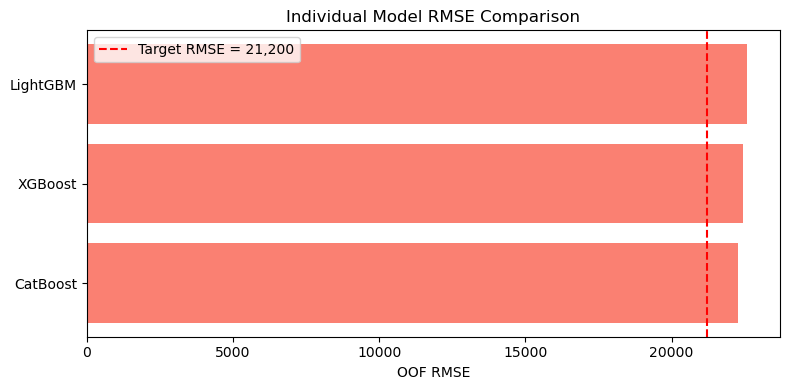

In [9]:
summary = pd.DataFrame({
    "Model": list(results.keys()),
    "OOF_RMSE": [results[k][2] for k in results],
}).sort_values("OOF_RMSE")
summary["vs_Target"] = summary["OOF_RMSE"] - 21200
summary = summary.reset_index(drop=True)
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["green" if r < 21200 else "salmon" for r in summary["OOF_RMSE"]]
ax.barh(summary["Model"], summary["OOF_RMSE"], color=colors)
ax.axvline(21200, color="red", linestyle="--", label="Target RMSE = 21,200")
ax.set_xlabel("OOF RMSE")
ax.set_title("Individual Model RMSE Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Blend — Weighted Average (Top 3 Tree Models)

In [10]:
# Weighted average of LightGBM, XGBoost, CatBoost
# Weights inversely proportional to RMSE
tree_models = ["LightGBM", "XGBoost", "CatBoost"]
inv_rmse = {k: 1.0 / results[k][2] for k in tree_models}
total = sum(inv_rmse.values())
weights = {k: v / total for k, v in inv_rmse.items()}
print("Blend weights (inverse RMSE):")
for k, w in weights.items():
    print(f"  {k}: {w:.4f}")

oof_blend_weighted = sum(weights[k] * results[k][0] for k in tree_models)
rmse_blend_weighted = np.sqrt(mean_squared_error(y, oof_blend_weighted))
print(f"\nWeighted Blend (Top 3 Trees) OOF RMSE = {rmse_blend_weighted:,.2f}")

Blend weights (inverse RMSE):
  LightGBM: 0.3312
  XGBoost: 0.3332
  CatBoost: 0.3356

Weighted Blend (Top 3 Trees) OOF RMSE = 22,234.05


## 9. Blend 2 — Optimized Weights (Scipy)

In [11]:
from scipy.optimize import minimize

# Optimize weights across the 3 tree models to minimize RMSE
model_names = list(results.keys())
oof_matrix = np.column_stack([results[k][0] for k in model_names])

def blend_rmse(w):
    w = np.array(w)
    w = w / w.sum()  # normalize
    blend = oof_matrix @ w
    return np.sqrt(mean_squared_error(y, blend))

# Initial guess: equal weights
x0 = np.ones(len(model_names)) / len(model_names)
bounds = [(0, 1)] * len(model_names)
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

res = minimize(blend_rmse, x0, method="SLSQP", bounds=bounds, constraints=constraints)
opt_weights = res.x / res.x.sum()

print("Optimized blend weights:")
for name, w in zip(model_names, opt_weights):
    print(f"  {name}: {w:.4f}")

oof_blend_opt = oof_matrix @ opt_weights
rmse_blend_opt = np.sqrt(mean_squared_error(y, oof_blend_opt))
print(f"\nOptimized Blend OOF RMSE = {rmse_blend_opt:,.2f}")

Optimized blend weights:
  LightGBM: 0.0277
  XGBoost: 0.3649
  CatBoost: 0.6075

Optimized Blend OOF RMSE = 22,171.64


## 9. Feature Importance (LightGBM)

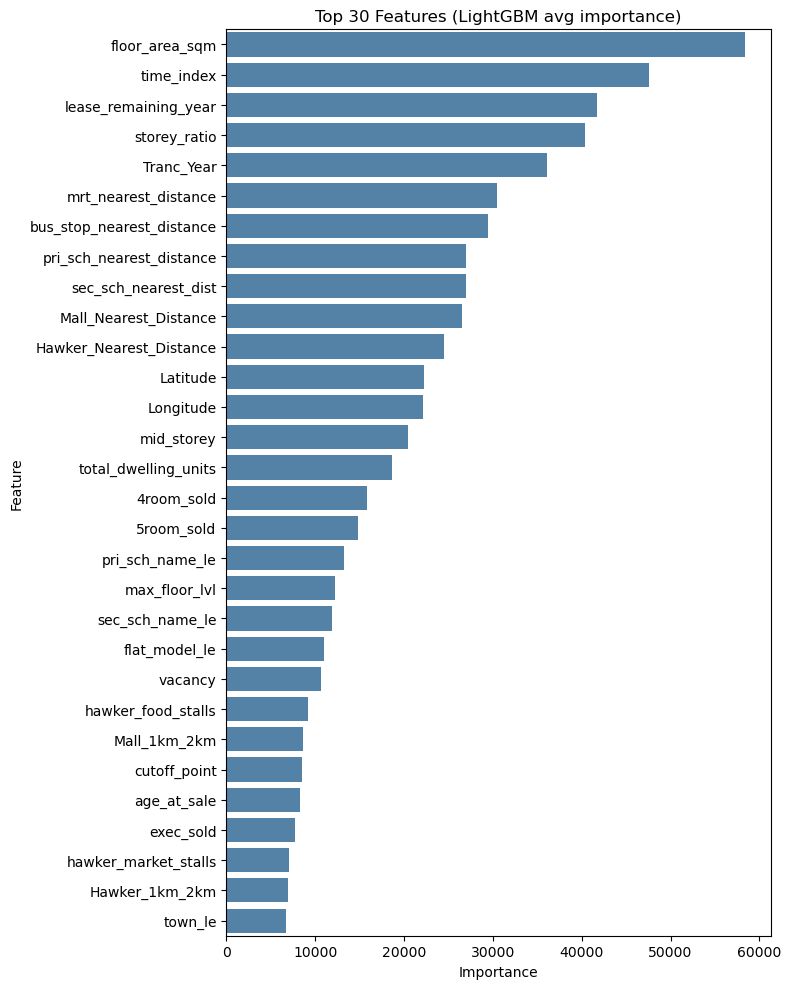

                  Feature  Importance
           floor_area_sqm     58386.8
               time_index     47607.2
     lease_remaining_year     41705.0
             storey_ratio     40357.2
               Tranc_Year     36095.6
     mrt_nearest_distance     30499.8
bus_stop_nearest_distance     29429.6
 pri_sch_nearest_distance     26954.2
     sec_sch_nearest_dist     26943.0
    Mall_Nearest_Distance     26486.4
  Hawker_Nearest_Distance     24507.8
                 Latitude     22220.6
                Longitude     22126.2
               mid_storey     20483.8
     total_dwelling_units     18681.4
               4room_sold     15818.6
               5room_sold     14784.2
          pri_sch_name_le     13250.6
            max_floor_lvl     12208.2
          sec_sch_name_le     11924.0


In [12]:
# Average feature importance across folds from the LightGBM models
importances = np.zeros(len(tree_feature_cols))
for m in models_lgbm:
    importances += m.feature_importances_
importances /= len(models_lgbm)

feat_imp = pd.DataFrame({
    "Feature": tree_feature_cols,
    "Importance": importances,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 10))
top_n = min(30, len(feat_imp))
sns.barplot(data=feat_imp.head(top_n), x="Importance", y="Feature", ax=ax, color="steelblue")
ax.set_title(f"Top {top_n} Features (LightGBM avg importance)")
plt.tight_layout()
plt.show()

print(feat_imp.head(20).to_string(index=False))

## 10. Final Results Summary

FINAL RESULTS SUMMARY
              Model     OOF_RMSE  vs_Target_21200  Beat_Target
    Blend_Optimized 22171.644901       971.644901        False
Blend_Weighted_Top3 22234.050901      1034.050901        False
           CatBoost 22281.790922      1081.790922        False
            XGBoost 22442.875228      1242.875228        False
           LightGBM 22577.583661      1377.583661        False

Best model: Blend_Optimized with RMSE = 22,171.64
Target NOT met. Gap: 971.64


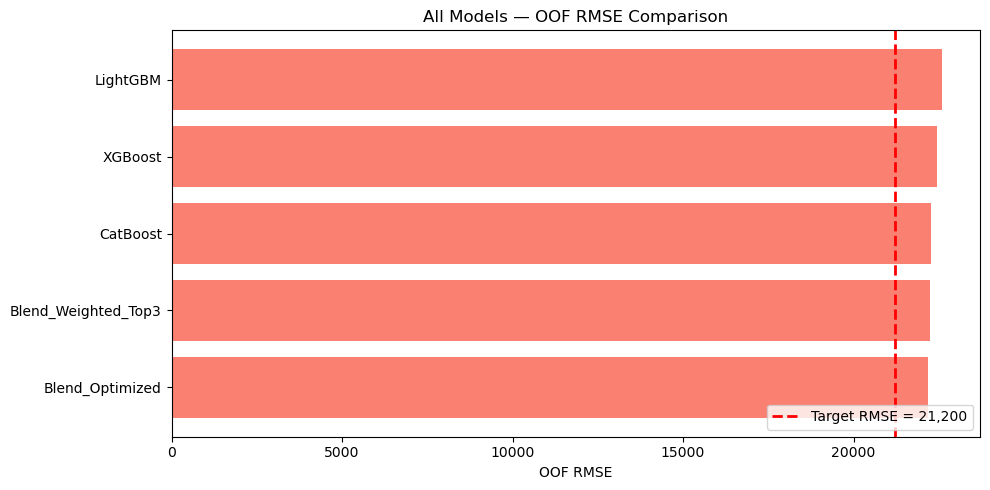

In [13]:
# Collect all results including blends
all_results = {k: v[2] for k, v in results.items()}
all_results["Blend_Weighted_Top3"] = rmse_blend_weighted
all_results["Blend_Optimized"] = rmse_blend_opt

final_df = pd.DataFrame({
    "Model": list(all_results.keys()),
    "OOF_RMSE": list(all_results.values()),
}).sort_values("OOF_RMSE").reset_index(drop=True)
final_df["vs_Target_21200"] = final_df["OOF_RMSE"] - 21200
final_df["Beat_Target"] = final_df["OOF_RMSE"] < 21200

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(final_df.to_string(index=False))
print("=" * 60)

best = final_df.iloc[0]
print(f"\nBest model: {best['Model']} with RMSE = {best['OOF_RMSE']:,.2f}")
if best["OOF_RMSE"] < 21200:
    print("TARGET MET: RMSE < 21,200")
else:
    print(f"Target NOT met. Gap: {best['OOF_RMSE'] - 21200:,.2f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["green" if r < 21200 else "salmon" for r in final_df["OOF_RMSE"]]
ax.barh(final_df["Model"], final_df["OOF_RMSE"], color=colors)
ax.axvline(21200, color="red", linestyle="--", linewidth=2, label="Target RMSE = 21,200")
ax.set_xlabel("OOF RMSE")
ax.set_title("All Models — OOF RMSE Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()